In [49]:
import pandas as pd

# Load datasets
df_main = pd.read_csv(r"C:\Users\thiru\Downloads\GFS_Project_Horizon.csv")
df_delay = pd.read_csv(r"C:\Users\thiru\Downloads\delay_labels.csv")

# Merge datasets on shipment_id
df = pd.merge(df_main, df_delay, on="shipment_id")

# Convert date (optional)
df['shipment_date'] = pd.to_datetime(df['shipment_date'], errors='coerce')

C:\Users\thiru\AppData\Local\Temp\ipykernel_4052\2499313056.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['shipment_date'] = pd.to_datetime(df['shipment_date'], errors='coerce')


In [50]:
df.head()

,shipment_id,shipment_date,shipment_type,shipment_priority,shipment_weight_kg,shipment_volume_cbm,supplier_id,supplier_rating,supplier_region,supplier_previous_delay_count,...,fuel_cost,penalty_cost,complaint_flag,customer_satisfaction_score,shipment_color_code,warehouse_manager_id,routing_template_version,supplier_internal_code,operational_cluster_id,delay_flag
0,100000,2026-04-22,Sea,High,9394.775965,84.876421,1865,61.208770,North,4,...,1576.340239,0.0,0,4.337561,Red,5474,9,729300,12,0
1,100001,2024-05-31,Air,Medium,23770.321945,49.957187,1967,91.458610,West,3,...,8352.386264,0.0,0,4.554302,White,7975,2,298350,8,0
2,100002,2023-08-05,Rail,High,18313.248848,20.351095,1317,85.724354,West,2,...,597.586783,0.0,0,3.653195,Green,2548,6,313143,11,0
3,100003,2023-09-21,Air,Low,14986.529181,73.927537,1590,70.881880,West,0,...,6966.003921,0.0,0,3.541624,Blue,7846,1,215148,11,0
4,100004,2025-11-23,Air,Critical,3942.665079,42.449135,1696,NaN,South,3,...,6517.599749,0.0,0,3.442475,Red,5236,4,540993,15,0


## Feature Engineering

We engineer features in the following stages:
1. **Drop leakage & raw-identifier columns** — `penalty_cost`, `complaint_flag`, and `customer_satisfaction_score` are *consequences* of a shipment being delayed (a penalty/complaint/low CSAT is recorded after the fact), so using them to *predict* `delay_flag` would leak the target. Raw high-cardinality IDs (`supplier_id`, `warehouse_id`, `route_id`, `warehouse_manager_id`, `supplier_internal_code`) carry no generalizable signal on their own (up to ~48k unique values) and are dropped in favor of the descriptive attributes already provided for each entity (rating, utilization, distance, etc.).
2. **Clean messy categories** — `supplier_region` has inconsistent casing/abbreviations (`N`, `NORTH`, `North`, `north`) that need normalizing before encoding.
3. **Handle missing values** — e.g. `supplier_rating` has NaNs.
4. **Date features** — month, day-of-week, quarter, weekend flag from `shipment_date`.
5. **Domain-derived ratio/interaction features** — speed, cost efficiency, density, lead time, composite risk scores.
6. **Encode categoricals** — ordinal encoding for ordered categories (`shipment_priority`, `customer_tier`), one-hot for nominal ones.
7. **Feature selection** — combine correlation, mutual information, and Random Forest importance into a single ranking and select the top contributing features.

In [51]:
import numpy as np

df_fe = df.copy()

# --- 1. Drop leakage columns (recorded AFTER a delay outcome is known) ---
leakage_cols = ['penalty_cost', 'complaint_flag', 'customer_satisfaction_score']

# --- 1b. Drop raw high-cardinality identifier columns (no standalone signal) ---
id_cols = ['shipment_id', 'supplier_id', 'warehouse_id', 'route_id',
           'warehouse_manager_id', 'supplier_internal_code']

df_fe = df_fe.drop(columns=leakage_cols + id_cols)

print("Dropped leakage columns:", leakage_cols)
print("Dropped raw ID columns:", id_cols)
print("Remaining shape:", df_fe.shape)

Dropped leakage columns: ['penalty_cost', 'complaint_flag', 'customer_satisfaction_score']
Dropped raw ID columns: ['shipment_id', 'supplier_id', 'warehouse_id', 'route_id', 'warehouse_manager_id', 'supplier_internal_code']
Remaining shape: (50500, 31)


In [52]:
# --- 2. Clean messy categorical text (supplier_region has inconsistent casing/abbreviations) ---
df_fe['supplier_region'] = (
    df_fe['supplier_region']
    .str.strip()
    .str.upper()
    .replace({'N': 'NORTH'})
    .str.title()
)
print(df_fe['supplier_region'].value_counts())

supplier_region
North    14084
West     12347
South    12107
East     11962
Name: count, dtype: int64


In [53]:
# --- 3. Missing value handling ---
missing = df_fe.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)

# Track which rows were imputed with a missing-indicator flag (useful signal in itself),
# then impute: median for numeric, mode for categorical.
for col in missing.index:
    if df_fe[col].dtype in ['float64', 'int64']:
        df_fe[f'{col}_was_missing'] = df_fe[col].isna().astype(int)
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())
    else:
        df_fe[f'{col}_was_missing'] = df_fe[col].isna().astype(int)
        df_fe[col] = df_fe[col].fillna(df_fe[col].mode()[0])

print("\nRemaining missing values:", df_fe.isna().sum().sum())

Columns with missing values:
 vehicle_age_years    5158
rainfall_mm          5060
supplier_rating      5048
dtype: int64

Remaining missing values: 0


In [54]:
# --- 4. Date-derived features ---
df_fe['shipment_month'] = df_fe['shipment_date'].dt.month
df_fe['shipment_quarter'] = df_fe['shipment_date'].dt.quarter
df_fe['shipment_dayofweek'] = df_fe['shipment_date'].dt.dayofweek
df_fe['shipment_is_weekend'] = (df_fe['shipment_dayofweek'] >= 5).astype(int)

df_fe = df_fe.drop(columns=['shipment_date'])
df_fe[['shipment_month', 'shipment_quarter', 'shipment_dayofweek', 'shipment_is_weekend']].head()

,shipment_month,shipment_quarter,shipment_dayofweek,shipment_is_weekend
0,4,2,2,0
1,5,2,4,0
2,8,3,5,1
3,9,3,3,0
4,11,4,6,1


In [55]:
# --- 5. Domain-derived ratio & interaction features ---
eps = 1e-6  # avoid divide-by-zero

# Shipment density (kg per cubic metre) - dense/heavy shipments may load & move differently
df_fe['shipment_density'] = df_fe['shipment_weight_kg'] / (df_fe['shipment_volume_cbm'] + eps)

# Cost efficiency
df_fe['transport_cost_per_kg'] = df_fe['transportation_cost'] / (df_fe['shipment_weight_kg'] + eps)
df_fe['transport_cost_per_km'] = df_fe['transportation_cost'] / (df_fe['route_distance_km'] + eps)
df_fe['fuel_cost_per_km'] = df_fe['fuel_cost'] / (df_fe['route_distance_km'] + eps)

# Route speed pressure - low implied speed vs distance can signal an unrealistic/at-risk schedule
df_fe['avg_speed_kmph'] = df_fe['route_distance_km'] / (df_fe['estimated_travel_time_hrs'] + eps)

# End-to-end estimated operational lead time (warehouse handling + transit)
df_fe['total_lead_time_hrs'] = df_fe['warehouse_processing_time_hrs'] + df_fe['estimated_travel_time_hrs']

# Vehicle condition risk
df_fe['maintenance_overdue_flag'] = (df_fe['maintenance_overdue_days'] > 0).astype(int)
df_fe['vehicle_risk_score'] = df_fe['vehicle_age_years'] + df_fe['maintenance_overdue_days']

# Adverse weather composite (storm OR heavy rainfall, using the 75th percentile as "heavy")
rainfall_p75 = df_fe['rainfall_mm'].quantile(0.75)
df_fe['adverse_weather_flag'] = (
    (df_fe['storm_warning'] == 1) | (df_fe['rainfall_mm'] > rainfall_p75)
).astype(int)

# Supplier risk index - combines past delay frequency with (inverse) rating into one score
df_fe['supplier_risk_index'] = df_fe['supplier_previous_delay_count'] / (df_fe['supplier_rating'] + 1)

# Warehouse pressure - absolute units in use, not just the percentage
df_fe['warehouse_units_in_use'] = df_fe['warehouse_capacity'] * (df_fe['warehouse_utilization_pct'] / 100)

new_feature_cols = ['shipment_density', 'transport_cost_per_kg', 'transport_cost_per_km',
                     'fuel_cost_per_km', 'avg_speed_kmph', 'total_lead_time_hrs',
                     'maintenance_overdue_flag', 'vehicle_risk_score', 'adverse_weather_flag',
                     'supplier_risk_index', 'warehouse_units_in_use']
df_fe[new_feature_cols].describe()

,shipment_density,transport_cost_per_kg,transport_cost_per_km,fuel_cost_per_km,avg_speed_kmph,total_lead_time_hrs,maintenance_overdue_flag,vehicle_risk_score,adverse_weather_flag,supplier_risk_index,warehouse_units_in_use
count,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000
mean,598.450037,4.293501,11.486938,3.505558,54.968242,40.514342,0.992792,12.448158,0.310535,0.037595,20603.349430
std,1446.421424,17.585713,2.020510,0.865662,8.664161,17.225253,0.084594,4.424918,0.462717,0.022229,10613.765706
min,0.556248,0.002770,8.000073,2.000001,40.000344,2.241663,0.000000,1.000000,0.000000,0.000000,1357.934521
25%,123.676662,0.705066,9.736570,2.760467,47.382666,26.472461,1.000000,9.000000,0.000000,0.022938,11741.548604
50%,248.670657,1.390085,11.496324,3.509137,55.000271,39.859361,1.000000,12.000000,0.000000,0.035719,19895.604902
75%,488.364912,2.784760,13.231208,4.255786,62.486206,53.310695,1.000000,16.000000,1.000000,0.050247,28380.885405
max,76436.604227,799.277708,14.999935,4.999959,69.999251,96.867109,1.000000,29.000000,1.000000,0.208406,49988.000000


In [56]:
# --- 6. Encode categoricals ---

# Ordinal encoding for naturally ordered categories
priority_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
tier_map = {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}

df_fe['shipment_priority'] = df_fe['shipment_priority'].map(priority_map)
df_fe['customer_tier'] = df_fe['customer_tier'].map(tier_map)

# One-hot encoding for nominal categories (including low-cardinality operational IDs)
nominal_cols = ['shipment_type', 'supplier_region', 'vehicle_type', 'customer_region',
                'shipment_color_code', 'routing_template_version', 'operational_cluster_id']

df_encoded = pd.get_dummies(df_fe, columns=nominal_cols, drop_first=True)

print("Shape before encoding:", df_fe.shape)
print("Shape after one-hot encoding:", df_encoded.shape)

Shape before encoding: (50500, 48)
Shape after one-hot encoding: (50500, 83)


## Feature Selection

In [57]:
y = df_encoded['delay_flag']
X = df_encoded.drop(columns=['delay_flag'])

# Make sure every column is numeric (bool -> int) for the selection methods below
X = X.apply(lambda c: c.astype(int) if c.dtype == bool else c)

print("X shape:", X.shape, "| y distribution:\n", y.value_counts(normalize=True))

X shape: (50500, 82) | y distribution:
 delay_flag
0    0.84701
1    0.15299
Name: proportion, dtype: float64


In [58]:
# --- Method 1: Point-biserial correlation of each feature with the binary target ---
corr_with_target = X.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_target.head(20)

storm_warning                    0.411747
warehouse_utilization_pct        0.228850
adverse_weather_flag             0.179372
route_risk_score                 0.138983
supplier_previous_delay_count    0.099265
supplier_risk_index              0.095760
warehouse_units_in_use           0.083661
maintenance_overdue_days         0.023456
operational_cluster_id_12        0.011085
shipment_type_Rail              -0.010421
vehicle_risk_score               0.009380
inventory_available              0.007796
customer_region_North           -0.007789
operational_cluster_id_17        0.007624
shipment_type_Road               0.007389
operational_cluster_id_2         0.007374
avg_speed_kmph                  -0.007204
shipment_type_Sea                0.007136
supplier_rating_was_missing     -0.007023
operational_cluster_id_18       -0.006601
dtype: float64

In [59]:
# --- Method 2: Mutual information (captures non-linear relationships, unlike correlation) ---
from sklearn.feature_selection import mutual_info_classif

# Handle any remaining NaNs before mutual_info_classif (it can't accept them)
X = X.dropna()
y = y.loc[X.index]

mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
mi_series.head(20)

storm_warning                    0.058456
warehouse_utilization_pct        0.048114
route_risk_score                 0.016252
adverse_weather_flag             0.015447
supplier_previous_delay_count    0.014701
supplier_risk_index              0.010834
maintenance_overdue_flag         0.006217
warehouse_units_in_use           0.006133
supplier_region_North            0.005244
transport_cost_per_kg            0.005059
shipment_is_weekend              0.004696
shipment_month                   0.004040
shipment_type_Rail               0.003705
shipment_quarter                 0.003289
operational_cluster_id_7         0.002932
supplier_rating                  0.002899
shipment_priority                0.002822
routing_template_version_6       0.002716
customer_region_North            0.002546
shipment_color_code_Red          0.002354
dtype: float64

In [60]:
# --- Method 3: Random Forest feature importance (captures interactions, robust to scale) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_importance.head(20)

storm_warning                    0.129965
warehouse_utilization_pct        0.127074
route_risk_score                 0.061730
rainfall_mm                      0.036717
supplier_risk_index              0.030422
warehouse_units_in_use           0.027869
supplier_previous_delay_count    0.024569
warehouse_capacity               0.021865
transport_cost_per_km            0.021754
inventory_available              0.021662
shipment_volume_cbm              0.021529
fuel_cost_per_km                 0.021309
temperature                      0.021281
avg_speed_kmph                   0.021086
supplier_rating                  0.020641
shipment_weight_kg               0.020588
warehouse_processing_time_hrs    0.020281
warehouse_cost                   0.020272
shipment_density                 0.020022
transport_cost_per_kg            0.019525
dtype: float64

In [61]:
# --- Combine all three methods into a single ranking ---
# Each method uses a different scale, so rank features (1 = most important) within each
# method, then average the ranks. This is more robust than averaging raw scores.
summary = pd.DataFrame({
    'abs_corr': corr_with_target.abs(),
    'mutual_info': mi_series,
    'rf_importance': rf_importance,
})

summary['rank_corr'] = summary['abs_corr'].rank(ascending=False)
summary['rank_mi'] = summary['mutual_info'].rank(ascending=False)
summary['rank_rf'] = summary['rf_importance'].rank(ascending=False)
summary['avg_rank'] = summary[['rank_corr', 'rank_mi', 'rank_rf']].mean(axis=1)

feature_ranking = summary.sort_values('avg_rank')
feature_ranking.head(25)

,abs_corr,mutual_info,rf_importance,rank_corr,rank_mi,rank_rf,avg_rank
storm_warning,0.411747,0.058456,0.129965,1.0,1.0,1.0,1.000000
warehouse_utilization_pct,0.228850,0.048114,0.127074,2.0,2.0,2.0,2.000000
route_risk_score,0.138983,0.016252,0.061730,4.0,3.0,3.0,3.333333
supplier_previous_delay_count,0.099265,0.014701,0.024569,5.0,5.0,7.0,5.666667
supplier_risk_index,0.095760,0.010834,0.030422,6.0,6.0,5.0,5.666667
warehouse_units_in_use,0.083661,0.006133,0.027869,7.0,8.0,6.0,7.000000
adverse_weather_flag,0.179372,0.015447,0.015757,3.0,4.0,26.0,11.000000
transport_cost_per_kg,0.004845,0.005059,0.019525,28.0,10.0,20.0,19.333333
rainfall_mm,0.004871,0.001657,0.036717,27.0,31.0,4.0,20.666667
maintenance_overdue_days,0.023456,0.001826,0.015305,8.0,28.0,27.0,21.000000


In [62]:
# --- Select the top-N features by combined rank for downstream modelling ---
TOP_N = 15
selected_features = feature_ranking.head(TOP_N).index.tolist()

print(f"Top {TOP_N} features selected for modelling:")
for i, f in enumerate(selected_features, 1):
    print(f"{i:2d}. {f}")

X_selected = X[selected_features]

Top 15 features selected for modelling:
 1. storm_warning
 2. warehouse_utilization_pct
 3. route_risk_score
 4. supplier_previous_delay_count
 5. supplier_risk_index
 6. warehouse_units_in_use
 7. adverse_weather_flag
 8. transport_cost_per_kg
 9. rainfall_mm
10. maintenance_overdue_days
11. avg_speed_kmph
12. shipment_type_Rail
13. shipment_weight_kg
14. customer_region_North
15. temperature


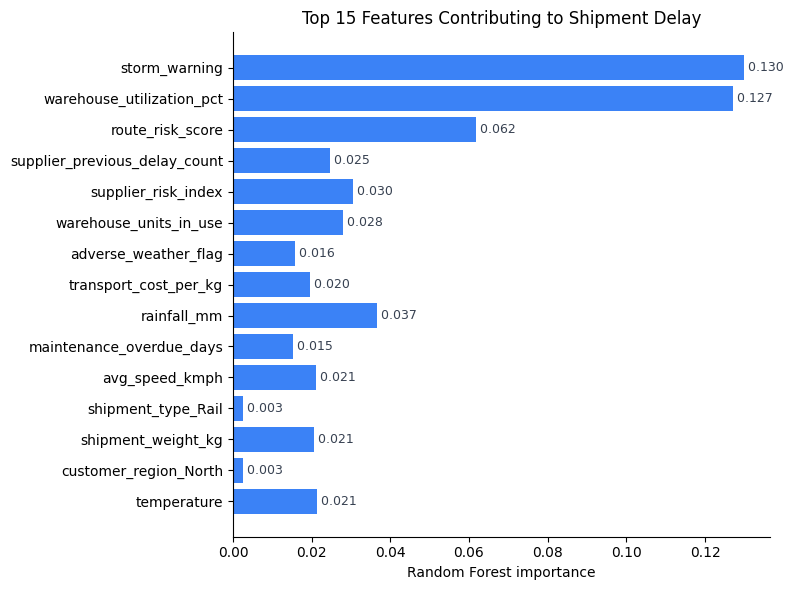

In [63]:
# --- Visualize the top features by combined importance ---
import matplotlib.pyplot as plt

plot_data = feature_ranking.head(TOP_N).iloc[::-1]  # smallest avg_rank (best) at top of barh

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(plot_data.index, plot_data['rf_importance'], color='#3B82F6')

ax.set_xlabel('Random Forest importance')
ax.set_title(f'Top {TOP_N} Features Contributing to Shipment Delay')
ax.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, plot_data['rf_importance']):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f' {val:.3f}',
            va='center', fontsize=9, color='#374151')

plt.tight_layout()
plt.show()

### Notes on the selection

- `X_selected` / `selected_features` carry the top-`TOP_N` columns and are what should feed the modelling stage (instead of the full `X`).
- Because `y` is imbalanced (check the printed distribution above), Random Forest importance and mutual information are weighted more heavily in practice than raw correlation — correlation is included mainly as a fast linear sanity check.
- If a later modelling step wants the *encoded* full dataset (not just the top-N), use `X` / `df_encoded` directly — nothing beyond that point depends on `TOP_N`.
- Re-run this feature-selection block after any change upstream (e.g. adding a new derived feature) — rankings are computed fresh from `X`/`y` each time, nothing is hardcoded.

## Class Imbalance Check

Before trusting the feature ranking above (and before modelling on `X_selected`), check how skewed `delay_flag` is — a skewed target can (a) make `avg_speed_kmph`-style rankings misleading if computed naively, and (b) require `class_weight='balanced'` or resampling at the modelling stage.

In [64]:
# --- Overall target distribution ---
class_counts = y.value_counts().sort_index()
class_pct = (y.value_counts(normalize=True).sort_index() * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class counts (delay_flag):\n", class_counts)
print("\nClass percentages (%):\n", class_pct)
print(f"\nImbalance ratio (majority : minority) = {imbalance_ratio:.2f} : 1")

if imbalance_ratio >= 4:
    print("\n=> Strong imbalance: use class_weight='balanced', F1/PR-AUC (not accuracy), "
          "and consider SMOTE/undersampling at the modelling stage.")
elif imbalance_ratio >= 1.5:
    print("\n=> Moderate imbalance: prefer class_weight='balanced' and F1/ROC-AUC over accuracy.")
else:
    print("\n=> Roughly balanced: standard metrics/training should be fine.")

Class counts (delay_flag):
 delay_flag
0    42774
1     7726
Name: count, dtype: int64

Class percentages (%):
 delay_flag
0    84.7
1    15.3
Name: proportion, dtype: float64

Imbalance ratio (majority : minority) = 5.54 : 1

=> Strong imbalance: use class_weight='balanced', F1/PR-AUC (not accuracy), and consider SMOTE/undersampling at the modelling stage.


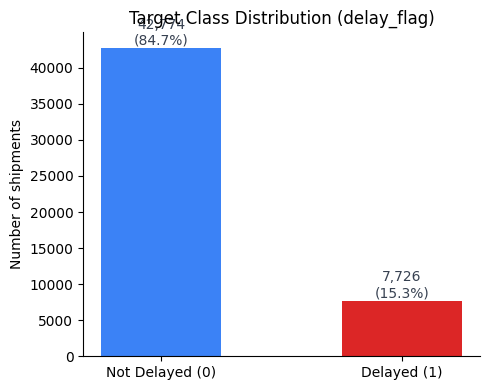

In [65]:
# --- Visualize the target distribution ---
labels = ['Not Delayed (0)', 'Delayed (1)']
colors = ['#3B82F6', '#DC2626']  # neutral blue = good outcome, red = critical/delayed outcome

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, class_counts.values, color=colors, width=0.5)

ax.set_ylabel('Number of shipments')
ax.set_title('Target Class Distribution (delay_flag)')
ax.spines[['top', 'right']].set_visible(False)

for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{count:,}\n({pct}%)', ha='center', va='bottom', fontsize=10, color='#374151')

plt.tight_layout()
plt.show()

In [66]:
# --- Confirm the stratified train/test split (used for rf_importance above) preserved this ratio ---
print("Full y distribution:\n", y.value_counts(normalize=True).round(4))
print("\nTrain split distribution:\n", y_train.value_counts(normalize=True).round(4))
print("\nTest split distribution:\n", y_test.value_counts(normalize=True).round(4))

Full y distribution:
 delay_flag
0    0.847
1    0.153
Name: proportion, dtype: float64

Train split distribution:
 delay_flag
0    0.847
1    0.153
Name: proportion, dtype: float64

Test split distribution:
 delay_flag
0    0.847
1    0.153
Name: proportion, dtype: float64


## Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) is applied **only to the training split**, never to the test split — the test set must keep the original class distribution so evaluation metrics reflect real-world performance. We reuse the exact same `X_train`/`X_test`/`y_train`/`y_test` row split created earlier (during Random Forest importance), just restricted to the `selected_features` from feature selection.

Requires the `imbalanced-learn` package: `pip install imbalanced-learn` (import name is `imblearn`).

In [67]:
# --- Restrict the existing train/test split to the selected features ---
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

print("Train class distribution BEFORE SMOTE:\n", y_train.value_counts())
print("\nTest class distribution (untouched):\n", y_test.value_counts())

Train class distribution BEFORE SMOTE:
 delay_flag
0    34219
1     6181
Name: count, dtype: int64

Test class distribution (untouched):
 delay_flag
0    8555
1    1545
Name: count, dtype: int64


In [68]:
# --- Apply SMOTE to the training split only ---
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)

print("Train class distribution AFTER SMOTE:\n", y_train_res.value_counts())
print("\nTrain shape before:", X_train_sel.shape, "-> after:", X_train_res.shape)

Train class distribution AFTER SMOTE:
 delay_flag
1    34219
0    34219
Name: count, dtype: int64

Train shape before: (40400, 15) -> after: (68438, 15)


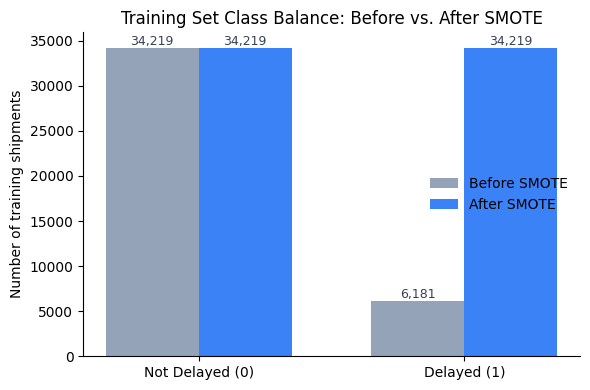

In [69]:
# --- Visualize training-set balance before vs. after SMOTE ---
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_res.value_counts().sort_index()

labels = ['Not Delayed (0)', 'Delayed (1)']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars_before = ax.bar(x - width / 2, before_counts.values, width, label='Before SMOTE', color='#94A3B8')
bars_after = ax.bar(x + width / 2, after_counts.values, width, label='After SMOTE', color='#3B82F6')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Number of training shipments')
ax.set_title('Training Set Class Balance: Before vs. After SMOTE')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)

for bars in (bars_before, bars_after):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height()):,}',
                ha='center', va='bottom', fontsize=9, color='#374151')

plt.tight_layout()
plt.show()

### Notes for model building

- Train every model on **`X_train_res`, `y_train_res`** (SMOTE-balanced) — never on `X_train_sel`/`y_train` directly if you want the balanced version.
- Evaluate every model on **`X_test_sel`, `y_test`** (original, untouched distribution) — this is what makes the evaluation trustworthy.
- Still prefer F1 / PR-AUC / recall on the minority (delayed) class over raw accuracy — SMOTE fixes the *training* skew, but a trivial "always predict 0" model can still look good on accuracy alone.
- If you swap in a different feature set later, rebuild `X_train_sel`/`X_test_sel` (and re-run SMOTE) — `X_train_res`/`y_train_res` are frozen to whatever `selected_features` was at the time this cell last ran.

## Model Building — ML & ANN

Rules followed for every model below:
- **Train** on `X_train_res` / `y_train_res` (SMOTE-balanced).
- **Evaluate** on `X_test_sel` / `y_test` (original, untouched distribution).
- **Judge by F1 / PR-AUC / recall on the minority (delayed = 1) class**, not raw accuracy — accuracy is still reported for reference but never used to pick a winner.

Models: Logistic Regression (linear baseline), Random Forest, Gradient Boosting (`HistGradientBoostingClassifier` — built into scikit-learn, no extra install), and an ANN built with Keras/TensorFlow.

In [70]:
# --- Shared evaluation helper: every model reports the same metrics on the SAME test set ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix)

model_results = []

def evaluate_model(model_name, y_true, y_pred, y_proba):
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'pr_auc': average_precision_score(y_true, y_proba),
    }
    model_results.append(metrics)

    print(f"--- {model_name} ---")
    print(classification_report(y_true, y_pred, target_names=['Not Delayed', 'Delayed']))
    print("Confusion matrix (rows=actual, cols=predicted):\n", confusion_matrix(y_true, y_pred))
    print(f"ROC-AUC: {metrics['roc_auc']:.4f} | PR-AUC: {metrics['pr_auc']:.4f}\n")
    return metrics

In [71]:
# --- Scale features (needed for Logistic Regression and the ANN; tree models use unscaled data) ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test_sel)

print("Scaled train shape:", X_train_scaled.shape, "| Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (68438, 15) | Scaled test shape: (10100, 15)


In [72]:
# --- Model 1: Logistic Regression (linear baseline) ---
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_res)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr)

--- Logistic Regression ---
              precision    recall  f1-score   support

 Not Delayed       0.92      0.77      0.84      8555
     Delayed       0.33      0.63      0.44      1545

    accuracy                           0.75     10100
   macro avg       0.63      0.70      0.64     10100
weighted avg       0.83      0.75      0.78     10100

Confusion matrix (rows=actual, cols=predicted):
 [[6606 1949]
 [ 569  976]]
ROC-AUC: 0.7653 | PR-AUC: 0.4536



{'model': 'Logistic Regression',
 'accuracy': 0.7506930693069307,
 'precision': 0.3336752136752137,
 'recall': 0.6317152103559871,
 'f1': 0.4366890380313199,
 'roc_auc': 0.7652876967802095,
 'pr_auc': 0.45358496934960624}

In [73]:
# --- Model 2: Random Forest (unscaled data — tree splits are scale-invariant) ---
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test_sel)
y_proba_rf = rf_model.predict_proba(X_test_sel)[:, 1]

evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf)

--- Random Forest ---
              precision    recall  f1-score   support

 Not Delayed       0.93      0.86      0.90      8555
     Delayed       0.46      0.67      0.55      1545

    accuracy                           0.83     10100
   macro avg       0.70      0.76      0.72     10100
weighted avg       0.86      0.83      0.84     10100

Confusion matrix (rows=actual, cols=predicted):
 [[7355 1200]
 [ 513 1032]]
ROC-AUC: 0.8407 | PR-AUC: 0.5377



{'model': 'Random Forest',
 'accuracy': 0.8303960396039604,
 'precision': 0.46236559139784944,
 'recall': 0.6679611650485436,
 'f1': 0.5464654487688642,
 'roc_auc': 0.8407103474755958,
 'pr_auc': 0.5377376616623704}

In [74]:
# --- Model 3: Gradient Boosting (HistGradientBoostingClassifier — scikit-learn native) ---
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train_res, y_train_res)

y_pred_hgb = hgb_model.predict(X_test_sel)
y_proba_hgb = hgb_model.predict_proba(X_test_sel)[:, 1]

evaluate_model('Gradient Boosting', y_test, y_pred_hgb, y_proba_hgb)

--- Gradient Boosting ---
              precision    recall  f1-score   support

 Not Delayed       0.93      0.85      0.89      8555
     Delayed       0.45      0.66      0.53      1545

    accuracy                           0.82     10100
   macro avg       0.69      0.76      0.71     10100
weighted avg       0.86      0.82      0.84     10100

Confusion matrix (rows=actual, cols=predicted):
 [[7292 1263]
 [ 528 1017]]
ROC-AUC: 0.8432 | PR-AUC: 0.5613



{'model': 'Gradient Boosting',
 'accuracy': 0.8226732673267326,
 'precision': 0.44605263157894737,
 'recall': 0.658252427184466,
 'f1': 0.5317647058823529,
 'roc_auc': 0.8432112033501105,
 'pr_auc': 0.5613153087470186}

### Model 4: Artificial Neural Network (Keras / TensorFlow)

Requires `tensorflow`: `pip install tensorflow` if not already installed. Uses the same scaled data as Logistic Regression (`X_train_scaled`/`X_test_scaled`) since ANNs are sensitive to feature scale.

In [75]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid'),
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = ann_model.fit(
    X_train_scaled, y_train_res,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1, 
)

c:\Users\thiru\anaconda3\envs\ai_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
856/856 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7424 - loss: 0.5296 - val_accuracy: 0.6419 - val_loss: 0.6485
Epoch 2/50
856/856 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7739 - loss: 0.4822 - val_accuracy: 0.6859 - val_loss: 0.6006
Epoch 3/50
856/856 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7842 - loss: 0.4655 - val_accuracy: 0.6960 - val_loss: 0.5889
Epoch 4/50
856/856 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7896 - loss: 0.4563 - val_accuracy: 0.7199 - val_loss: 0.5622
Epoch 5/50
856/856 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7939 - loss: 0.4469 - val_accuracy: 0.7196 - val_loss: 0.5620
Epoch 6/50
856/856 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7974 - loss: 0.4429 - val_accuracy: 0.7393 - val_loss: 0.5167
Epoch 7/50
856/856 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7991 - loss: 0.4380 - val_accuracy: 0.7328 - val_loss: 0.5312
Epoch 8/50
856/856 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8004 - loss: 0.4350 - val_accuracy: 0.

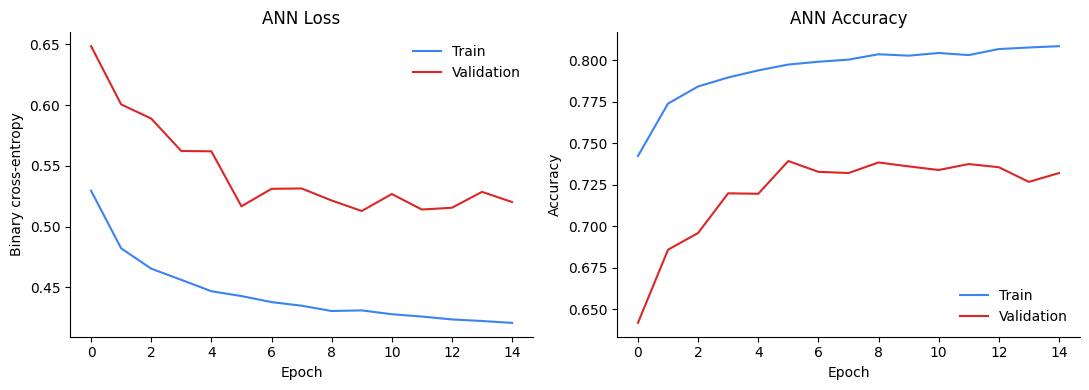

In [76]:
# --- ANN training curves (loss & accuracy) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history['loss'], label='Train', color='#3B82F6')
axes[0].plot(history.history['val_loss'], label='Validation', color='#DC2626')
axes[0].set_title('ANN Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary cross-entropy')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].legend(frameon=False)

axes[1].plot(history.history['accuracy'], label='Train', color='#3B82F6')
axes[1].plot(history.history['val_accuracy'], label='Validation', color='#DC2626')
axes[1].set_title('ANN Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

In [77]:
# --- Evaluate the ANN on the SAME untouched test set as every other model ---
y_proba_ann = ann_model.predict(X_test_scaled).ravel()
y_pred_ann = (y_proba_ann >= 0.5).astype(int)

evaluate_model('ANN (Keras)', y_test, y_pred_ann, y_proba_ann)

316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step
--- ANN (Keras) ---
              precision    recall  f1-score   support

 Not Delayed       0.92      0.88      0.90      8555
     Delayed       0.47      0.59      0.52      1545

    accuracy                           0.84     10100
   macro avg       0.70      0.73      0.71     10100
weighted avg       0.85      0.84      0.84     10100

Confusion matrix (rows=actual, cols=predicted):
 [[7532 1023]
 [ 637  908]]
ROC-AUC: 0.8320 | PR-AUC: 0.5070



{'model': 'ANN (Keras)',
 'accuracy': 0.8356435643564356,
 'precision': 0.4702226825479026,
 'recall': 0.5877022653721683,
 'f1': 0.522439585730725,
 'roc_auc': 0.8320034651096371,
 'pr_auc': 0.5069845450725143}

In [78]:
# --- Compare all models, ranked by F1 on the delayed (minority) class ---
results_df = pd.DataFrame(model_results).set_index('model')
results_df = results_df.sort_values('f1', ascending=False)

print("Ranked by F1 (delayed class) — NOT by accuracy:")
results_df[['f1', 'pr_auc', 'recall', 'precision', 'roc_auc', 'accuracy']].round(4)

Ranked by F1 (delayed class) — NOT by accuracy:


,f1,pr_auc,recall,precision,roc_auc,accuracy
model,,,,,,
Random Forest,0.5465,0.5377,0.6680,0.4624,0.8407,0.8304
Gradient Boosting,0.5318,0.5613,0.6583,0.4461,0.8432,0.8227
ANN (Keras),0.5224,0.5070,0.5877,0.4702,0.8320,0.8356
Logistic Regression,0.4367,0.4536,0.6317,0.3337,0.7653,0.7507


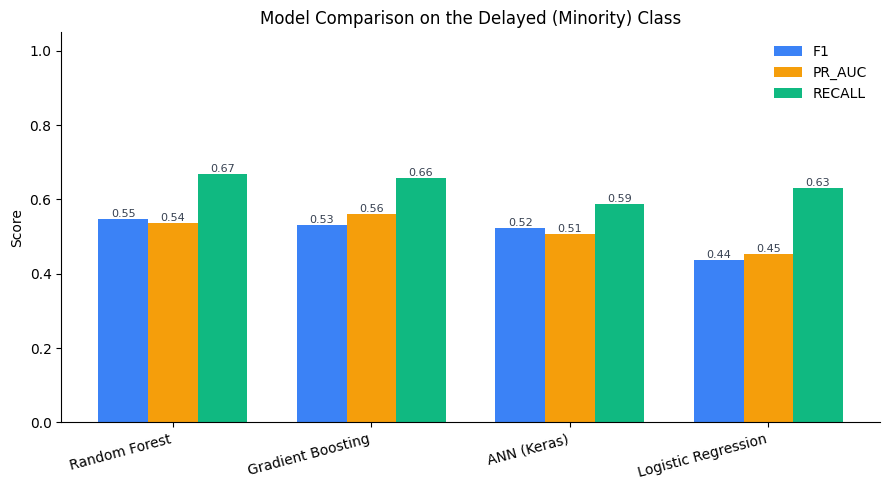

In [79]:
# --- Visualize F1 / PR-AUC / Recall across models (the metrics that matter for this task) ---
plot_metrics = ['f1', 'pr_auc', 'recall']
plot_df = results_df[plot_metrics]

x = np.arange(len(plot_df.index))
width = 0.25
colors = ['#3B82F6', '#F59E0B', '#10B981']  # fixed hue per metric, consistent across the figure

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, color) in enumerate(zip(plot_metrics, colors)):
    bars = ax.bar(x + (i - 1) * width, plot_df[metric], width, label=metric.upper(), color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8, color='#374151')

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison on the Delayed (Minority) Class')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### Notes on model selection

- The best model is whichever tops `results_df` on **F1** (with PR-AUC and recall as tie-breakers) — check the printed table and chart above once this has been run, don't assume it here.
- A high-accuracy / low-recall model is actively bad for this problem: missing an actual delay (false negative) is usually costlier than a false alarm, so recall on the delayed class matters more than it would in a balanced problem.
- All four models saw the identical SMOTE-balanced training data and the identical untouched test set, so the comparison above is apples-to-apples.
- If the ANN underperforms the tree models (common on tabular data of this size), that's an expected result, not a bug — gradient boosting / random forest typically win on structured/tabular data; the ANN is included because it was requested, not because it's expected to be the best performer here.

## Export Model & Artifacts for the Prediction App

The Streamlit app in `app/app.py` needs everything required to turn a single raw shipment entry into the exact feature vector the Gradient Boosting model (`hgb_model`) was trained on:
- the trained model itself,
- the full training-time column layout (`X.columns`) — needed to one-hot encode a single new row *correctly* (see the note in the app about why `pd.get_dummies` can't be used directly on one row),
- the ordinal maps, the adverse-weather rainfall threshold, and the valid category values for every dropdown,
- risk thresholds (75th percentile of each risk feature) used to flag "why" a shipment is risky,
- global permutation importance, so the app can show what the model weighs most heavily overall.

In [80]:
# --- Global permutation importance for the Gradient Boosting model (on the untouched test set) ---
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    hgb_model, X_test_sel, y_test, n_repeats=10, random_state=42, scoring='f1', n_jobs=-1
)
gb_importance = pd.Series(perm_result.importances_mean, index=selected_features).sort_values(ascending=False)
gb_importance

warehouse_utilization_pct        0.143463
supplier_risk_index              0.143303
adverse_weather_flag             0.122965
rainfall_mm                      0.117070
supplier_previous_delay_count    0.115184
storm_warning                    0.096447
route_risk_score                 0.051728
customer_region_North            0.004427
avg_speed_kmph                   0.002876
warehouse_units_in_use           0.001199
transport_cost_per_kg            0.000620
maintenance_overdue_days        -0.000196
temperature                     -0.000908
shipment_weight_kg              -0.002350
shipment_type_Rail              -0.004488
dtype: float64

In [81]:
# --- Save everything the app needs to reproduce the pipeline + predict ---
import os
import joblib

os.makedirs('app', exist_ok=True)

category_values = {col: sorted(df_fe[col].dropna().unique().tolist()) for col in nominal_cols}

risk_thresholds = {
    'supplier_risk_index_p75': float(df_fe['supplier_risk_index'].quantile(0.75)),
    'route_risk_score_p75': float(df_fe['route_risk_score'].quantile(0.75)),
    'vehicle_risk_score_p75': float(df_fe['vehicle_risk_score'].quantile(0.75)),
    'warehouse_utilization_p75': float(df_fe['warehouse_utilization_pct'].quantile(0.75)),
}

artifacts = {
    'model': hgb_model,
    'selected_features': selected_features,
    'all_columns': X.columns.tolist(),
    'nominal_cols': nominal_cols,
    'priority_map': priority_map,
    'tier_map': tier_map,
    'rainfall_p75': float(rainfall_p75),
    'category_values': category_values,
    'risk_thresholds': risk_thresholds,
    'gb_feature_importance': gb_importance.to_dict(),
}

joblib.dump(artifacts, 'app/model_artifacts.pkl')
print('Saved app/model_artifacts.pkl')
print('Selected features used by the model:')
for f in selected_features:
    print(' -', f)

Saved app/model_artifacts.pkl
Selected features used by the model:
 - storm_warning
 - warehouse_utilization_pct
 - route_risk_score
 - supplier_previous_delay_count
 - supplier_risk_index
 - warehouse_units_in_use
 - adverse_weather_flag
 - transport_cost_per_kg
 - rainfall_mm
 - maintenance_overdue_days
 - avg_speed_kmph
 - shipment_type_Rail
 - shipment_weight_kg
 - customer_region_North
 - temperature


### Running the app

1. Run every cell in this notebook top-to-bottom at least once (so `app/model_artifacts.pkl` exists).
2. `pip install -r app/requirements.txt`
3. `cd app && streamlit run app.py`

Re-run the export cell above (and restart the Streamlit app) any time the model, `selected_features`, or the feature-engineering steps upstream change.

In [87]:
pip install -r app/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [89]:
cd app && streamlit run app.py

[WinError 2] The system cannot find the file specified: 'app && streamlit run app.py'
c:\Users\thiru\Downloads
